## Libraries

In [1]:
# !pip install -q tensorflow-docs

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.5/182.5 kB 3.6 MB/s eta 0:00:00


In [2]:
import os
import keras
from keras import layers
from keras.applications.densenet import DenseNet121
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import itertools
import imageio
from tensorflow_docs.vis import embed
import pickle
import random

In [3]:
MAX_SEQ_LENGTH = 60
NUM_FEATURES = 1024
FRAME_DIM = (160, 120)

BATCH_SIZE = 64
EPOCHS = 30

path_input = "/content/drive/MyDrive/HAR_Lab3_Data/HumanActions/"

## Data preparation


In [4]:
data_files = []
labels = []

action_names = os.listdir(path_input)[:-2]

# Taking videos path
for category in action_names:
    folder = os.path.join(path_input, category)
    for file_name in os.listdir(folder):
        name = os.path.join(path_input, category, file_name)

        labels.append(category)
        data_files.append(name)


# train, test split
train_list, test_list, train_label, test_label = train_test_split(data_files, labels, test_size=0.25, random_state=42)

print(f"Total videos for train: {len(train_list)}")
print(f"Total videos for test: {len(test_list)}")

Total videos for train: 449
Total videos for test: 150


### Features extractor - CNN Network

In [5]:
def build_feature_extractor():
    feature_extractor = keras.applications.InceptionV3(
        weights="imagenet",
        include_top=False,
        pooling="avg",
        input_shape=(FRAME_DIM[1], FRAME_DIM[0], 3),
    )
    preprocess_input = keras.applications.inception_v3.preprocess_input

    inputs = keras.Input((FRAME_DIM[1], FRAME_DIM[0], 3))
    preprocessed = preprocess_input(inputs)

    outputs = feature_extractor(preprocessed)
    return keras.Model(inputs, outputs, name="feature_extractor")

In [6]:
## CNN for features extractor

def build_feature_extractor():
    feature_extractor = DenseNet121(
        weights="imagenet",
        include_top=False,
        pooling="avg",
        input_shape=(FRAME_DIM[1], FRAME_DIM[0], 3),
    )
    preprocess_input = keras.applications.densenet.preprocess_input

    inputs = keras.Input((FRAME_DIM[1], FRAME_DIM[0], 3))
    preprocessed = preprocess_input(inputs)

    outputs = feature_extractor(preprocessed)
    return keras.Model(inputs, outputs, name="feature_extractor")


In [8]:
feature_extractor = build_feature_extractor()

# Label preprocessing with StringLookup.
label_processor = keras.layers.StringLookup(
    num_oov_indices=0, vocabulary=action_names[:-1], mask_token=None
)
print(label_processor.get_vocabulary())

['walking', 'boxing', 'handclapping', 'running', 'handwaving', 'jogging']


## Extracting features

In [9]:
# Funtional functions for preparing data

def load_video(path, max_frames=0):
    cap = cv2.VideoCapture(path)
    frames = []
    try:
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            frames.append(frame)

            if len(frames) == max_frames:
                break
    finally:
        cap.release()
    return np.array(frames)


def prepare_all_videos(files, labels):
    num_samples = len(files)
    video_paths = files
    labels = tf.convert_to_tensor(label_processor(np.array(labels)[..., None])).numpy()


    # `frame_features` are what we will feed to our sequence model.
    frame_features = np.zeros(
        shape=(num_samples, MAX_SEQ_LENGTH, NUM_FEATURES), dtype="float32"
    )

    # For each video.
    for idx, path in enumerate(video_paths):
        # Gather all its frames and add a batch dimension.
        frames = load_video(path, max_frames=MAX_SEQ_LENGTH)
        frames = frames[None, ...]

        # Initialize placeholder to store the features of the current video.
        temp_frame_features = np.zeros(
            shape=(1, MAX_SEQ_LENGTH, NUM_FEATURES), dtype="float32"
        )

        # Extract features from the frames of the current video.
        for i, batch in enumerate(frames):
            # video_length = batch.shape[0]
            # length = min(MAX_SEQ_LENGTH, video_length)
            for j in range(MAX_SEQ_LENGTH):
                if np.mean(batch[j, :]) > 0.0:
                    temp_frame_features[i, j, :] = feature_extractor.predict(
                        batch[None, j, :]
                    )

                else:
                    temp_frame_features[i, j, :] = 0.0

        frame_features[idx,] = temp_frame_features.squeeze()

    return frame_features, labels

In [10]:
train_data, train_labels = prepare_all_videos(train_list, train_label)
print(f"Frame features in train set: {train_data[0].shape}")

test_data, test_labels = prepare_all_videos(test_list, test_label)
print(f"Frame masks in test set: {test_data[0].shape}")

Streaming output truncated to the last 5000 lines.
1/1 [==============================] - 0s 93ms/step
Frame masks in test set: (60, 1024)


In [13]:
# Reading
with open('/content/drive/MyDrive/datasets_trans.pkl', 'wb') as f:
  pickle.dump((train_data, train_labels, test_data, test_labels), f)

In [14]:
train_data.shape, test_data.shape

((449, 60, 1024), (150, 60, 1024))

## Transformer Model

In [15]:
# Position Embedding class
class PositionalEmbedding(layers.Layer):
    def __init__(self, sequence_length, output_dim, **kwargs):
        super().__init__(**kwargs)
        self.position_embeddings = layers.Embedding(
            input_dim=sequence_length, output_dim=output_dim
        )
        self.sequence_length = sequence_length
        self.output_dim = output_dim

    def build(self, input_shape):
        super().build(input_shape)

    def call(self, inputs):
        # The inputs are of shape: `(batch_size, frames, num_features)`
        inputs = tf.cast(inputs, self.compute_dtype)
        length = tf.shape(inputs)[1]
        positions = tf.range(start=0, limit=length, delta=1)
        embedded_positions = self.position_embeddings(positions)
        return inputs + embedded_positions

# Transofmer model
class TransformerEncoder(layers.Layer):
    def __init__(self, embed_dim, dense_dim, num_heads, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.dense_dim = dense_dim
        self.num_heads = num_heads
        self.attention = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=embed_dim, dropout=0.3
        )
        self.dense_proj = keras.Sequential(
            [
                layers.Dense(dense_dim, activation=keras.activations.gelu),
                layers.Dense(embed_dim),
            ]
        )
        self.layernorm_1 = layers.LayerNormalization()
        self.layernorm_2 = layers.LayerNormalization()

    def call(self, inputs, mask=None):
        attention_output = self.attention(inputs, inputs, attention_mask=mask)
        proj_input = self.layernorm_1(inputs + attention_output)
        proj_output = self.dense_proj(proj_input)
        return self.layernorm_2(proj_input + proj_output)


### Training

In [16]:
# Variables
sequence_length = MAX_SEQ_LENGTH
embed_dim = NUM_FEATURES
dense_dim = 4
num_heads = 1

# Classes
classes = len(label_processor.get_vocabulary())

inputs = keras.Input(shape=train_data.shape[1:])
x = PositionalEmbedding(
    sequence_length, embed_dim, name="frame_position_embedding"
)(inputs)
x = TransformerEncoder(embed_dim, dense_dim, num_heads, name="transformer_layer")(x)
x = layers.GlobalMaxPooling1D()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(classes, activation="softmax")(x)
model = keras.Model(inputs, outputs)

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)


In [18]:
filepath = "/content/drive/MyDrive/weights_class_transformers.h5"
checkpoint = keras.callbacks.ModelCheckpoint(
    filepath, save_weights_only=True, save_best_only=True, verbose=1
)

## Training
history = model.fit(
    train_data,
    train_labels,
    validation_split=0.15,
    epochs=EPOCHS,
    callbacks=[checkpoint],
)

# model.load_weights(filepath)
# Evaluation
_, accuracy = model.evaluate(test_data, test_labels)
print(f"Test accuracy: {round(accuracy * 100, 2)}%")


Epoch 1/30
12/12 [==============================] - ETA: 0s - loss: 4.1547 - accuracy: 0.3307
Epoch 1: val_loss improved from inf to 1.63062, saving model to /content/drive/MyDrive/weights_class_transformers.h5
12/12 [==============================] - 24s 2s/step - loss: 4.1547 - accuracy: 0.3307 - val_loss: 1.6306 - val_accuracy: 0.5000
Epoch 2/30
12/12 [==============================] - ETA: 0s - loss: 2.3929 - accuracy: 0.3832
Epoch 2: val_loss improved from 1.63062 to 1.45184, saving model to /content/drive/MyDrive/weights_class_transformers.h5
12/12 [==============================] - 20s 2s/step - loss: 2.3929 - accuracy: 0.3832 - val_loss: 1.4518 - val_accuracy: 0.3824
Epoch 3/30
12/12 [==============================] - ETA: 0s - loss: 1.5937 - accuracy: 0.4724
Epoch 3: val_loss improved from 1.45184 to 1.18017, saving model to /content/drive/MyDrive/weights_class_transformers.h5
12/12 [==============================] - 19s 2s/step - loss: 1.5937 - accuracy: 0.4724 - val_loss: 1.

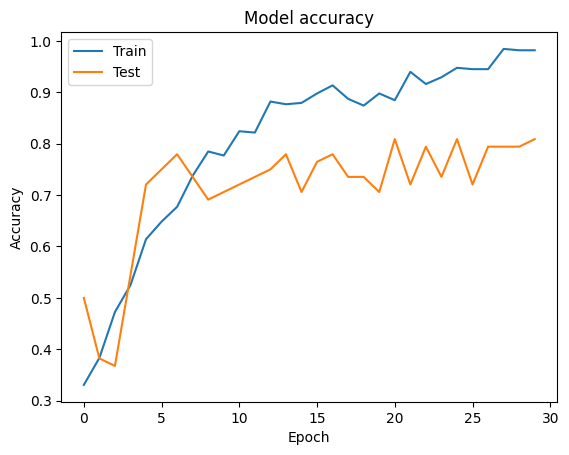

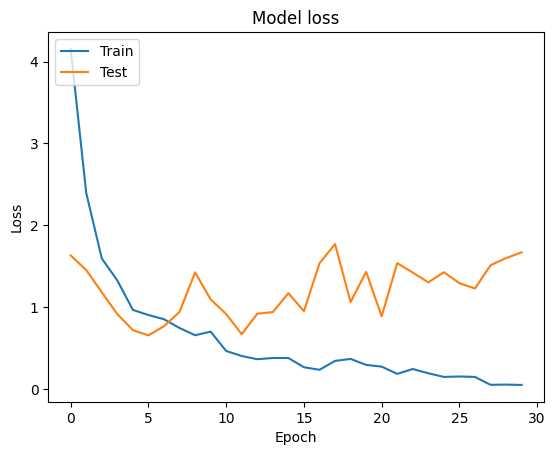

In [19]:
# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

### Predictions

5/5 [==============================] - 2s 406ms/step


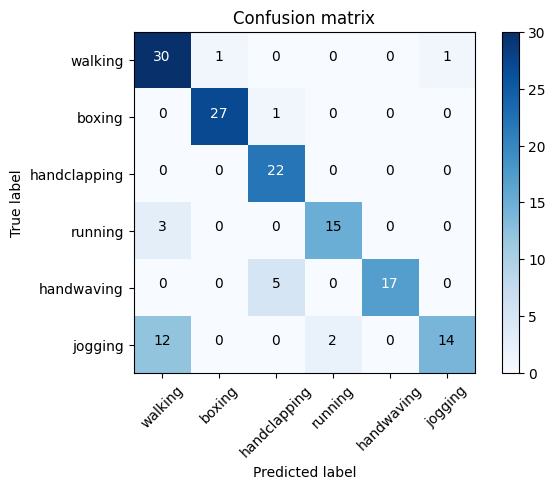

In [20]:
## Confusion matrix
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

Y_pred = model.predict(test_data)
Y_pred_classes = np.argmax(Y_pred,axis = 1)
confusion_mtx = confusion_matrix(test_labels, Y_pred_classes)
plot_confusion_matrix(confusion_mtx, classes = action_names[:-1])

### Visualizing predictions

In [21]:
def prepare_single_video(frames):
    frame_features = np.zeros(shape=(1, MAX_SEQ_LENGTH, NUM_FEATURES), dtype="float32")
    frames = frames[None, ...]

    # Extract features from the frames of the current video.
    for i, batch in enumerate(frames):
        video_length = batch.shape[0]
        length = min(MAX_SEQ_LENGTH, video_length)
        for j in range(length):
            if np.mean(batch[j, :]) > 0.0:
                frame_features[i, j, :] = feature_extractor.predict(batch[None, j, :])
            else:
                frame_features[i, j, :] = 0.0

    return frame_features


def predict_action(path):
    class_vocab = label_processor.get_vocabulary()

    frames = load_video(path)
    frame_features = prepare_single_video(frames)
    probabilities = model.predict(frame_features)[0]

    plot_x_axis, plot_y_axis = [], []

    for i in np.argsort(probabilities)[::-1]:
        plot_x_axis.append(class_vocab[i])
        plot_y_axis.append(probabilities[i])
        print(f"  {class_vocab[i]}: {probabilities[i] * 100:5.2f}%")

    plt.bar(plot_x_axis, plot_y_axis, label=plot_x_axis)
    plt.xlabel("class_label")
    plt.xlabel("Probability")
    plt.show()

    return frames


Test video path: /content/drive/MyDrive/HAR_Lab3_Data/HumanActions/handclapping/person25_handclapping_d4_uncomp.avi
1/1 [==============================] - 0s 79ms/step
  handclapping: 100.00%
  walking:  0.00%
  boxing:  0.00%
  handwaving:  0.00%
  jogging:  0.00%
  running:  0.00%


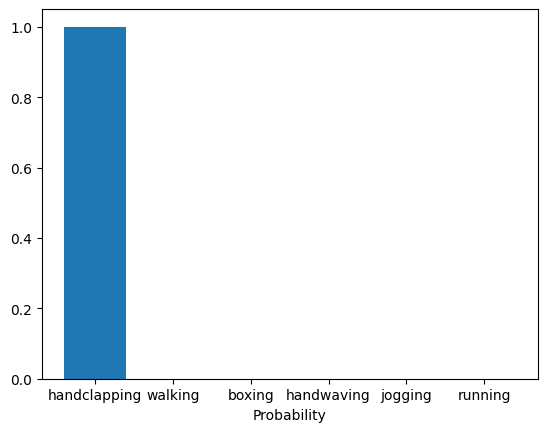

<Figure size 640x480 with 0 Axes>

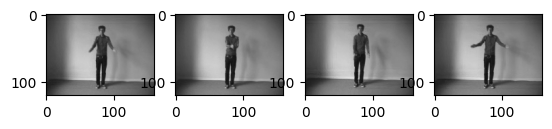

In [24]:
# Predicting
test_video = test_list[np.random.randint(len(test_data))]
print(f"Test video path: {test_video}")
test_frames = predict_action(test_video)

# Plotting
plt.figure()
f, axarr = plt.subplots(1,4)

frames = load_video(test_video)
frms = random.sample(range(0, len(frames)), 4)
axarr[0].imshow(frames[frms[0]])
axarr[1].imshow(frames[frms[1]])
axarr[2].imshow(frames[frms[2]])
axarr[3].imshow(frames[frms[3]])


Test video path: /content/drive/MyDrive/HAR_Lab3_Data/HumanActions/jogging/person10_jogging_d2_uncomp.avi
1/1 [==============================] - 0s 66ms/step
  walking: 99.11%
  jogging:  0.88%
  running:  0.01%
  handclapping:  0.00%
  boxing:  0.00%
  handwaving:  0.00%


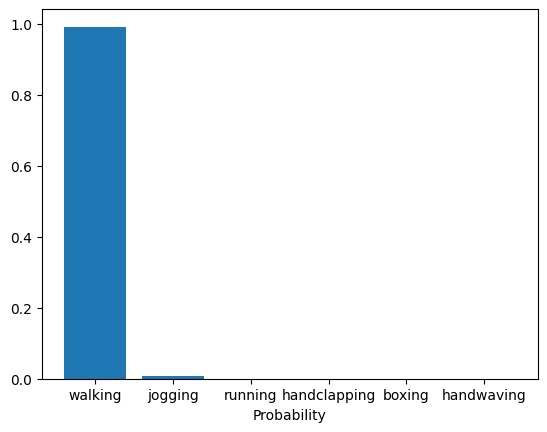

<Figure size 640x480 with 0 Axes>

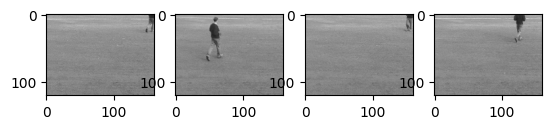

In [25]:
# Predicting
test_video = test_list[np.random.randint(len(test_data))]
print(f"Test video path: {test_video}")
test_frames = predict_action(test_video)

# Plotting
plt.figure()
f, axarr = plt.subplots(1,4)

frames = load_video(test_video)
frms = random.sample(range(0, len(frames)), 4)
axarr[0].imshow(frames[frms[0]])
axarr[1].imshow(frames[frms[1]])
axarr[2].imshow(frames[frms[2]])
axarr[3].imshow(frames[frms[3]])
